# Setup

In [1]:
from pathlib import Path
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "test"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_DIR exists: {TRAIN_DIR.exists()}")
print(f"TEST_DIR exists: {TEST_DIR.exists()}")

PROJECT_ROOT: c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-2026
TRAIN_DIR exists: True
TEST_DIR exists: True


# Build Metadata

In [2]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_train_metadata(train_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted([d for d in train_dir.iterdir() if d.is_dir()]):
        label = class_dir.name
        for p in sorted(class_dir.rglob("*")):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({
                    "split": "train",
                    "label": label,
                    "file_name": p.name,
                    "file_path": str(p),
                    "ext": p.suffix.lower(),
                    "file_size": p.stat().st_size,
                })
    return pd.DataFrame(rows)

def collect_test_metadata(test_dir: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(test_dir.rglob("*")):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            rows.append({
                "split": "test",
                "label": "unknown",
                "file_name": p.name,
                "file_path": str(p),
                "ext": p.suffix.lower(),
                "file_size": p.stat().st_size,
            })
    return pd.DataFrame(rows)

train_df = collect_train_metadata(TRAIN_DIR)
test_df = collect_test_metadata(TEST_DIR)
all_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Train images: {len(train_df)}")
print(f"Test images: {len(test_df)}")
print(f"All images: {len(all_df)}")
display(train_df.head())

Train images: 1652
Test images: 404
All images: 2056


,split,label,file_name,file_path,ext,file_size
0,train,fake_mannequin,mannequin_001.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,32708
1,train,fake_mannequin,mannequin_002.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,215315
2,train,fake_mannequin,mannequin_003.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,125622
3,train,fake_mannequin,mannequin_004.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,149177
4,train,fake_mannequin,mannequin_005.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,116652


# Class Distribution

,count,ratio
label,,
realperson,465,0.2815
fake_unknown,338,0.2046
fake_mask,278,0.1683
fake_screen,229,0.1386
fake_mannequin,224,0.1356
fake_printed,118,0.0714


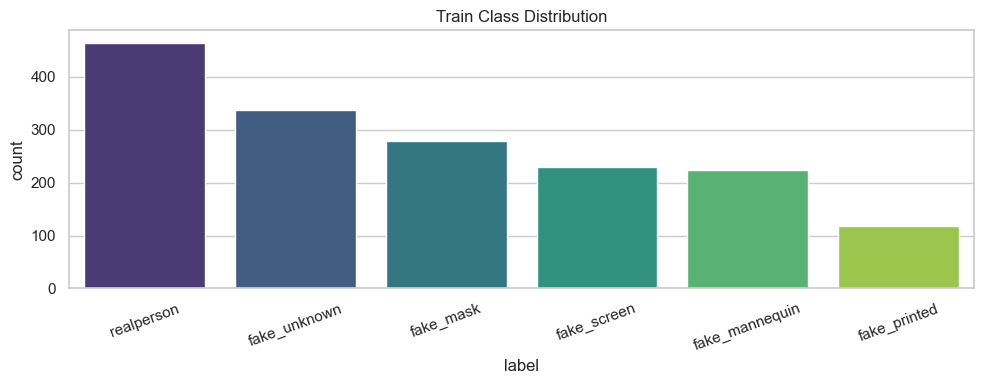

In [6]:
class_counts = train_df["label"].value_counts().sort_values(ascending=False)
class_ratio = (class_counts / class_counts.sum()).round(4)

display(pd.DataFrame({"count": class_counts, "ratio": class_ratio}))

plt.figure(figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", hue=class_counts.index, legend=False)
plt.xticks(rotation=20)
plt.title("Train Class Distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# File Format Check

,split,ext,count
1,test,.jpg,355
0,test,.jpeg,48
2,test,.png,1
4,train,.jpg,1273
3,train,.jpeg,376
5,train,.png,3


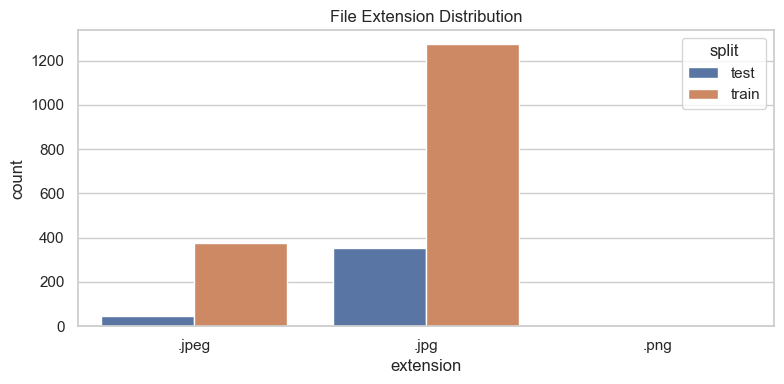

In [7]:
ext_by_split = all_df.groupby(["split", "ext"]).size().reset_index(name="count")
display(ext_by_split.sort_values(["split", "count"], ascending=[True, False]))

plt.figure(figsize=(8, 4))
sns.barplot(data=ext_by_split, x="ext", y="count", hue="split")
plt.title("File Extension Distribution")
plt.xlabel("extension")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Image Size Audit

Missing size rows: 0


,count,mean,std,min,5%,25%,50%,75%,95%,max
width,2056.0,1073.772374,877.139679,168.00,256.0000,360.0000,959.00,1280.0,3024.000000,5664.000000
height,2056.0,1534.442121,1253.444821,183.00,256.0000,480.0000,1280.00,1920.0,3840.000000,6528.000000
aspect_ratio,2056.0,0.789227,0.243680,0.33,0.5625,0.5625,0.75,1.0,1.333333,2.113208


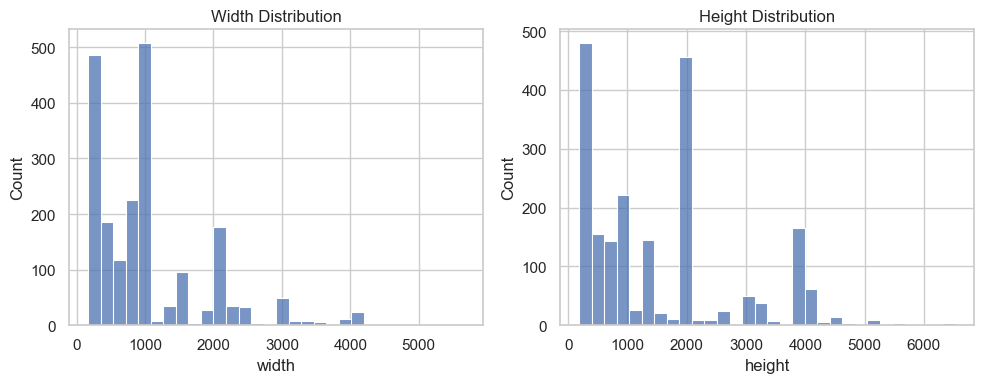

In [8]:
def read_size(path: str):
    try:
        with Image.open(path) as img:
            w, h = img.size
            return w, h
    except Exception:
        return np.nan, np.nan

size_df = all_df.copy()
size_df[["width", "height"]] = size_df["file_path"].apply(
    lambda p: pd.Series(read_size(p))
)
size_df["aspect_ratio"] = size_df["width"] / size_df["height"]

print("Missing size rows:", int(size_df["width"].isna().sum()))
display(
    size_df[["width", "height", "aspect_ratio"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(size_df["width"].dropna(), bins=30, kde=False)
plt.title("Width Distribution")

plt.subplot(1, 2, 2)
sns.histplot(size_df["height"].dropna(), bins=30, kde=False)
plt.title("Height Distribution")
plt.tight_layout()
plt.show()

# Corrupt File Check

In [9]:
def verify_image(path: str) -> str:
    try:
        with Image.open(path) as img:
            img.verify()
        return "ok"
    except (UnidentifiedImageError, OSError, ValueError):
        return "corrupt"
    except Exception:
        return "error"

status_df = all_df[["split", "label", "file_name", "file_path"]].copy()
status_df["status"] = status_df["file_path"].apply(verify_image)

status_counts = status_df["status"].value_counts()
display(status_counts)

bad_files_df = status_df[status_df["status"] != "ok"].copy()
display(bad_files_df.head())
print(f"Bad files: {len(bad_files_df)}")

status
ok    2056
Name: count, dtype: int64

,split,label,file_name,file_path,status


Bad files: 0


# Duplicate Check

In [10]:
def file_md5(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hash_df = all_df[["split", "label", "file_name", "file_path"]].copy()
hash_df["md5"] = hash_df["file_path"].apply(file_md5)

dup_all = hash_df[hash_df.duplicated(subset=["md5"], keep=False)].sort_values("md5")
dup_train = hash_df[(hash_df["split"] == "train") & hash_df.duplicated(subset=["md5"], keep=False)].sort_values("md5")

train_hashes = set(hash_df.loc[hash_df["split"] == "train", "md5"])
test_hashes = set(hash_df.loc[hash_df["split"] == "test", "md5"])
cross_overlap = len(train_hashes.intersection(test_hashes))

print(f"Duplicate rows (all): {len(dup_all)}")
print(f"Duplicate rows (train): {len(dup_train)}")
print(f"Train-Test exact hash overlap: {cross_overlap}")
display(dup_all.head(20))

Duplicate rows (all): 507
Duplicate rows (train): 409
Train-Test exact hash overlap: 87


,split,label,file_name,file_path,md5
932,train,fake_unknown,unknown_084.jpeg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,00dabb668ccb433bf092e7d5bdab6953
503,train,fake_printed,printed_002.jpeg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,00dabb668ccb433bf092e7d5bdab6953
1659,test,unknown,test_008.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,00df868421c798af231288f879d52e46
153,train,fake_mannequin,mannequin_154.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,00df868421c798af231288f879d52e46
1983,test,unknown,test_332.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,019fe6c12646777b29fc9220a1d757be
154,train,fake_mannequin,mannequin_155.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,019fe6c12646777b29fc9220a1d757be
1840,test,unknown,test_189.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,0212731c7eb3da27868cfe456b4da15c
181,train,fake_mannequin,mannequin_182.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,0212731c7eb3da27868cfe456b4da15c
1210,train,realperson,real_024.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,02bf6ed47a6faeadecb3d406f89ea5c5
836,train,fake_screen,screen_217.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,02bf6ed47a6faeadecb3d406f89ea5c5


# Save Audit Outputs

In [11]:
train_df.to_csv(OUT_DIR / "train_metadata.csv", index=False)
test_df.to_csv(OUT_DIR / "test_metadata.csv", index=False)
size_df.to_csv(OUT_DIR / "image_size_audit.csv", index=False)
status_df.to_csv(OUT_DIR / "file_status_audit.csv", index=False)
dup_all.to_csv(OUT_DIR / "duplicates_exact_hash.csv", index=False)

summary = pd.DataFrame(
    {
        "metric": [
            "train_images",
            "test_images",
            "bad_files",
            "duplicate_rows_all",
            "duplicate_rows_train",
            "train_test_hash_overlap",
        ],
        "value": [
            len(train_df),
            len(test_df),
            len(bad_files_df),
            len(dup_all),
            len(dup_train),
            cross_overlap,
        ],
    }
)
summary.to_csv(OUT_DIR / "eda_summary_metrics.csv", index=False)

print(f"Saved audit files to: {OUT_DIR}")
display(summary)

Saved audit files to: c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-2026\data\processed\audit


,metric,value
0,train_images,1652
1,test_images,404
2,bad_files,0
3,duplicate_rows_all,507
4,duplicate_rows_train,409
5,train_test_hash_overlap,87
